<a href="https://colab.research.google.com/github/jkondev/code/blob/master/Two_component_Goodwin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LINEAR STABILITY ANALYSIS

Model:
  dM/dt = Mmax*(kp*P + kac*M)*(1-fM) - gammaM*M
  dP/dt = kM/(1+M^n) - P

Parameters:
  Mmax = 5.0, kp = 1, kac = 0, f = 0.1
  gammaM = 1, kM = 3.0, n = 4.0
  sigma = 0

Fixed point:
  M* = 1.614340
  P* = 0.385024

Jacobian at (M*, P*):
  J = [-1.192512  +4.192830]
      [-0.831571  -1.000000]

  J11 = -1.192512
       = Mmax*[kac*(1-f*M*) - f*(kp*P* + kac*M*)] - gammaM
       = autocatalytic gain - substrate depletion loss - degradation

  tr(J)  = -2.192512  (need > 0 for instability)
  det(J) = 4.679147  (need > 0 for spiral/focus)
  disc   = tr^2 - 4*det = -13.909478  (< 0 => oscillatory)

  Eigenvalues: -1.0963 +/- 1.8648i

  Natural frequency:  omega_0 = 1.8648
  Oscillation period: T_0     = 3.37
  Damping rate:       |Re|    = 1.0963
  Quality factor:     Q_osc   = 0.85

  Classification: STABLE SPIRAL

Hopf bifurcation condition: tr(J) > 0, i.e. J11 > 1
  --> J11 = -1.1925 < 0 (damping wins)
     distance to Hopf: need J11 to increase by 2.19

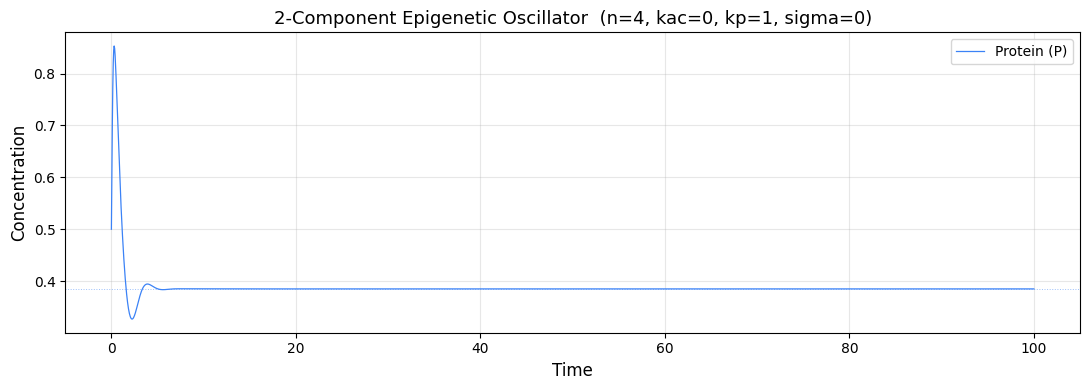

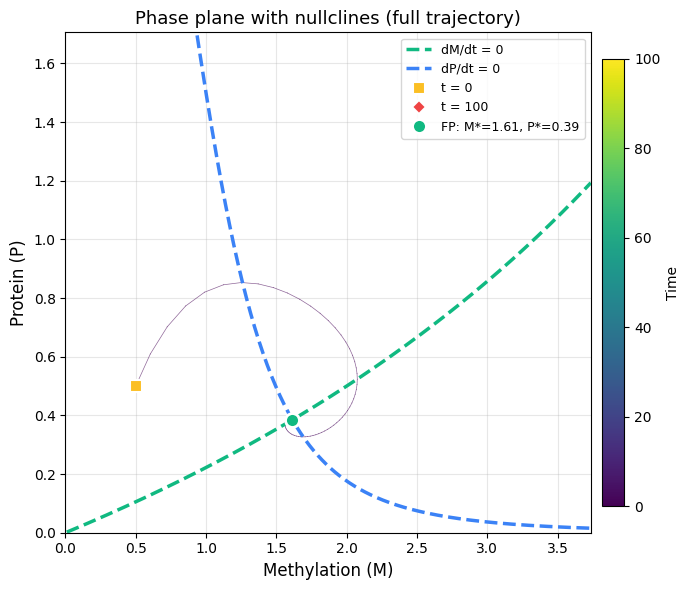

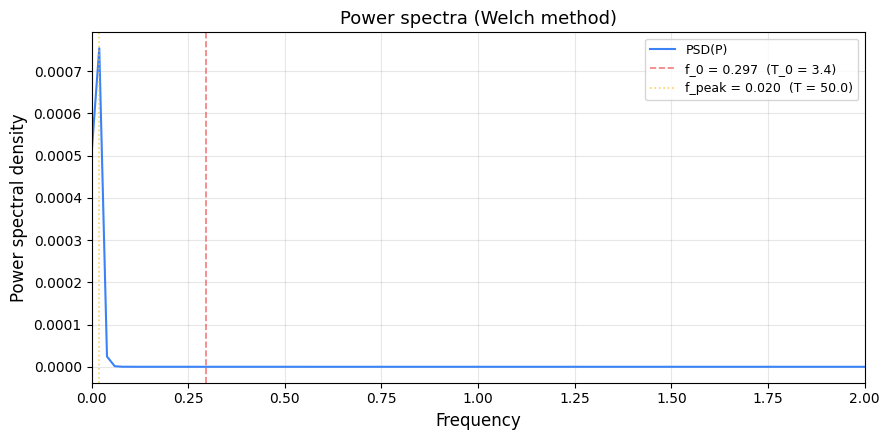

In [ ]:
# =============================================================================
# 2-Component Epigenetic Oscillator with Methylation Noise
#
# dM/dt = Mmax * (kp*P + kac*M) * (1 - f*M) - gammaM * M
# dP/dt = kM / (1 + M^n) - P
#
# Noise (Ito, multiplicative) on the methylation equation:
#   dM = [drift] dt + sigma * sqrt(rate) dW
#   where rate = Mmax * (kp*P + kac*M) * (1 - f*M)
#
# Integration: RK4 (sigma=0) or Euler-Maruyama (sigma>0)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ── Parameters ───────────────────────────────────────────────────────────────

# Methylation dynamics
Mmax = 5.0       # maximum methylation capacity
kp = 1         # enzyme-catalyzed methylation rate
kac = 0      # autocatalytic (reader-writer) rate
f = 0.1          # substrate saturation: physical max = 1/f = 10
gammaM = 1    # passive demethylation rate

# Protein dynamics (repressed by methylation)
kM = 3.0         # max protein production rate
n = 4.0          # Hill coefficient for repression

# Noise
sigma = 0      # methylation noise amplitude

# Numerics
dt = 0.005
t_max = 100.0
seed = 2025


# ── Simulation ───────────────────────────────────────────────────────────────

def methyl_production(M, P):
    # Total methylation rate before degradation.
    mp = max(M, 0.0)
    pp = max(P, 0.0)
    substrate = max(1.0 - f * mp, 0.0)
    return Mmax * (kp * pp + kac * mp) * substrate


def simulate(sigma_run, rng=None):
    # Integrate the model. Returns arrays t, M, P.

    if rng is None:
        rng = np.random.default_rng(seed)

    sqrt_dt = np.sqrt(dt)
    n_steps = int(round(t_max / dt))
    sample_every = max(1, int(round(0.05 / dt)))
    n_samples = n_steps // sample_every + 1

    t_out = np.empty(n_samples)
    M_out = np.empty(n_samples)
    P_out = np.empty(n_samples)

    M, P = 0.5, 0.5
    idx = 0

    for i in range(n_steps + 1):
        if i % sample_every == 0 and idx < n_samples:
            t_out[idx] = i * dt
            M_out[idx] = M
            P_out[idx] = P
            idx += 1

        def drift(m, p):
            mc = max(m, 0.0)
            pc = max(p, 0.0)
            sub = max(1.0 - f * mc, 0.0)
            rate = Mmax * (kp * pc + kac * mc) * sub
            hill = kM / (1.0 + mc ** n)
            return (rate - gammaM * m, hill - p)

        if sigma_run == 0:
            # RK4
            k1 = drift(M, P)
            k2 = drift(M + 0.5*dt*k1[0], P + 0.5*dt*k1[1])
            k3 = drift(M + 0.5*dt*k2[0], P + 0.5*dt*k2[1])
            k4 = drift(M + dt*k3[0], P + dt*k3[1])
            M += (dt / 6.0) * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
            P += (dt / 6.0) * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
        else:
            # Euler-Maruyama
            rate = methyl_production(M, P)
            hill = kM / (1.0 + max(M, 0.0) ** n)
            dW = rng.standard_normal() * sqrt_dt
            M += (rate - gammaM * M) * dt + sigma_run * np.sqrt(max(rate, 0.0)) * dW
            P += (hill - P) * dt

        M = max(M, 0.0)
        P = max(P, 0.0)

    return t_out[:idx], M_out[:idx], P_out[:idx]


# ── Fixed point and Jacobian ─────────────────────────────────────────────────

def find_fixed_point():
    # Iterate to find intersection of nullclines.
    M = 1.0
    for _ in range(10000):
        P = kM / (1.0 + max(M, 0.0) ** n)
        sub = max(1.0 - f * M, 0.001)
        rate = Mmax * (kp * P + kac * M) * sub
        M_new = rate / gammaM
        err = M_new - M
        M = M + 0.005 * err
        if abs(err) < 1e-12:
            break
    Mstar = max(M, 0.0)
    Pstar = kM / (1.0 + Mstar ** n)
    return Mstar, Pstar


def linear_stability(Mstar, Pstar):
    # Compute Jacobian, eigenvalues, and classify the fixed point.

    sub = max(1.0 - f * Mstar, 0.001)
    J11 = Mmax * (kac * sub - f * (kp * Pstar + kac * Mstar)) - gammaM
    J12 = Mmax * kp * sub
    hill_denom = 1.0 + Mstar ** n
    J21 = -kM * n * Mstar ** (n - 1) / (hill_denom ** 2)
    J22 = -1.0

    J = np.array([[J11, J12], [J21, J22]])
    tr = J11 + J22
    det = J11 * J22 - J12 * J21
    disc = tr ** 2 - 4 * det

    if disc >= 0:
        lam1 = tr / 2 + np.sqrt(disc) / 2
        lam2 = tr / 2 - np.sqrt(disc) / 2
        eigenvalues = (lam1, lam2)
        oscillatory = False
    else:
        lam_re = tr / 2
        lam_im = np.sqrt(-disc) / 2
        eigenvalues = (complex(lam_re, lam_im), complex(lam_re, -lam_im))
        oscillatory = True

    stable = np.real(eigenvalues[0]) < 0

    return {
        "J": J,
        "J11": J11,
        "trace": tr,
        "det": det,
        "disc": disc,
        "eigenvalues": eigenvalues,
        "oscillatory": oscillatory,
        "stable": stable,
    }


# ── Nullclines ───────────────────────────────────────────────────────────────

def compute_nullclines(m_range, n_pts=500):
    m_vals = np.linspace(m_range[0], m_range[1], n_pts)

    # P-nullcline: dP/dt = 0  =>  P = kM / (1 + M^n)
    P_null = kM / (1.0 + m_vals ** n)

    # M-nullcline: dM/dt = 0
    #   =>  P = [gammaM*M / (Mmax*(1-fM)) - kac*M] / kp
    sub = np.maximum(1.0 - f * m_vals, 1e-6)
    M_null_P = (gammaM * m_vals / (Mmax * sub) - kac * m_vals) / kp

    return m_vals, M_null_P, P_null


# =============================================================================
# RUN
# =============================================================================

rng = np.random.default_rng(seed)

# Simulate
t, M_traj, P_traj = simulate(sigma, rng)

# Fixed point and stability
Mstar, Pstar = find_fixed_point()
stab = linear_stability(Mstar, Pstar)


# ── Print stability analysis ────────────────────────────────────────────────

print("=" * 60)
print("LINEAR STABILITY ANALYSIS")
print("=" * 60)
print("")
print("Model:")
print("  dM/dt = Mmax*(kp*P + kac*M)*(1-fM) - gammaM*M")
print("  dP/dt = kM/(1+M^n) - P")
print("")
print("Parameters:")
print("  Mmax = {}, kp = {}, kac = {}, f = {}".format(Mmax, kp, kac, f))
print("  gammaM = {}, kM = {}, n = {}".format(gammaM, kM, n))
print("  sigma = {}".format(sigma))
print("")
print("Fixed point:")
print("  M* = {:.6f}".format(Mstar))
print("  P* = {:.6f}".format(Pstar))
print("")
print("Jacobian at (M*, P*):")
print("  J = [{:+.6f}  {:+.6f}]".format(stab["J"][0, 0], stab["J"][0, 1]))
print("      [{:+.6f}  {:+.6f}]".format(stab["J"][1, 0], stab["J"][1, 1]))
print("")
print("  J11 = {:.6f}".format(stab["J11"]))
print("       = Mmax*[kac*(1-f*M*) - f*(kp*P* + kac*M*)] - gammaM")
print("       = autocatalytic gain - substrate depletion loss - degradation")
print("")
print("  tr(J)  = {:.6f}  (need > 0 for instability)".format(stab["trace"]))
print("  det(J) = {:.6f}  (need > 0 for spiral/focus)".format(stab["det"]))
print("  disc   = tr^2 - 4*det = {:.6f}  (< 0 => oscillatory)".format(stab["disc"]))
print("")

if stab["oscillatory"]:
    lam = stab["eigenvalues"][0]
    omega = abs(lam.imag)
    damping = abs(lam.real)
    period = 2 * np.pi / omega if omega > 0 else float("inf")
    Q = omega / (2 * damping) if damping > 0 else float("inf")
    print("  Eigenvalues: {:.4f} +/- {:.4f}i".format(lam.real, abs(lam.imag)))
    print("")
    print("  Natural frequency:  omega_0 = {:.4f}".format(omega))
    print("  Oscillation period: T_0     = {:.2f}".format(period))
    print("  Damping rate:       |Re|    = {:.4f}".format(damping))
    print("  Quality factor:     Q_osc   = {:.2f}".format(Q))
else:
    print("  Eigenvalues: {:.4f}, {:.4f}  (real, non-oscillatory)".format(
        stab["eigenvalues"][0], stab["eigenvalues"][1]))

print("")
if stab["stable"]:
    kind = "STABLE SPIRAL" if stab["oscillatory"] else "STABLE NODE"
else:
    kind = "UNSTABLE SPIRAL (limit cycle expected)" if stab["oscillatory"] else "SADDLE / UNSTABLE NODE"
print("  Classification: {}".format(kind))
print("")
print("Hopf bifurcation condition: tr(J) > 0, i.e. J11 > 1")
if stab["J11"] > 1:
    print("  --> PAST Hopf: J11 = {:.4f} > 1".format(stab["J11"]))
elif stab["J11"] > 0:
    print("  --> J11 = {:.4f} > 0 (autocat overcomes damping)".format(stab["J11"]))
    print("     but still below Hopf: need J11 to increase by {:.4f}".format(1 - stab["J11"]))
else:
    print("  --> J11 = {:.4f} < 0 (damping wins)".format(stab["J11"]))
    print("     distance to Hopf: need J11 to increase by {:.4f}".format(1 - stab["J11"]))
print("=" * 60)


# ── Plot 1: Time series ─────────────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(11, 4))

#ax1.plot(t, M_traj, color="#10b981", lw=0.9, label="Methylation (M)")
ax1.plot(t, P_traj, color="#3b82f6", lw=0.9, label="Protein (P)")

#ax1.axhline(Mstar, color="#10b981", ls=":", lw=0.7, alpha=0.5)
ax1.axhline(Pstar, color="#3b82f6", ls=":", lw=0.7, alpha=0.5)

ax1.set_xlabel("Time", fontsize=12)
ax1.set_ylabel("Concentration", fontsize=12)
ax1.set_title(
    "2-Component Epigenetic Oscillator  "
    "(n={}, kac={}, kp={}, sigma={})".format(int(n), kac, kp, sigma),
    fontsize=13)
ax1.legend(loc="upper right", fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("time_series.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 2: Phase plane with nullclines (full trajectory) ────────────────────

fig2, ax2 = plt.subplots(figsize=(7, 6))

# Nullclines
m_upper = min(1.0 / f * 0.95, max(M_traj) * 1.8)
m_vals, M_null_P, P_null = compute_nullclines((0.01, m_upper))

# M-nullcline (filter to reasonable P range)
p_plot_max = max(np.max(P_traj) * 2.0, Pstar * 3.0)
mask = (M_null_P > -0.2) & (M_null_P < p_plot_max)
ax2.plot(m_vals[mask], M_null_P[mask], color="#10b981", lw=2.5, ls="--",
         label="dM/dt = 0", zorder=5)

# P-nullcline
ax2.plot(m_vals, P_null, color="#3b82f6", lw=2.5, ls="--",
         label="dP/dt = 0", zorder=5)

# Full trajectory — color coded by time
n_pts = len(M_traj)
colors = plt.cm.viridis(np.linspace(0, 1, n_pts))
for i in range(n_pts - 1):
    ax2.plot(M_traj[i:i+2], P_traj[i:i+2], color=colors[i], lw=0.5, alpha=0.6)

# Mark start and end
ax2.plot(M_traj[0], P_traj[0], "s", color="#fbbf24", ms=8, mew=1.5,
         mec="white", zorder=11, label="t = 0")
ax2.plot(M_traj[-1], P_traj[-1], "D", color="#ef4444", ms=7, mew=1.5,
         mec="white", zorder=11, label="t = {:.0f}".format(t_max))

# Fixed point
fp_color = "#10b981" if stab["stable"] else "#ef4444"
ax2.plot(Mstar, Pstar, "o", color=fp_color, ms=10, mew=2, mec="white",
         zorder=12, label="FP: M*={:.2f}, P*={:.2f}".format(Mstar, Pstar))

# Substrate saturation limit
#ax2.axvline(1.0 / f, color="#ef4444", ls=":", lw=1, alpha=0.4,
#            label="M = 1/f = {:.0f}".format(1.0 / f))

# Colorbar for time
sm = plt.cm.ScalarMappable(cmap="viridis",
                           norm=plt.Normalize(vmin=0, vmax=t_max))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, pad=0.02, fraction=0.04)
cbar.set_label("Time", fontsize=10)

ax2.set_xlabel("Methylation (M)", fontsize=12)
ax2.set_ylabel("Protein (P)", fontsize=12)
ax2.set_title("Phase plane with nullclines (full trajectory)", fontsize=13)
ax2.legend(loc="upper right", fontsize=9)
ax2.set_xlim(0, m_upper)
ax2.set_ylim(bottom=0, top=p_plot_max)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("phase_plane.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 3: Power spectral density ──────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(9, 4.5))

dt_sample = t[1] - t[0]
nperseg = min(1024, len(M_traj) // 2)

freqs_M, psd_M = welch(M_traj - np.mean(M_traj), fs=1.0/dt_sample,
                        nperseg=nperseg, detrend="linear", window="hann")
freqs_P, psd_P = welch(P_traj - np.mean(P_traj), fs=1.0/dt_sample,
                        nperseg=nperseg, detrend="linear", window="hann")

#ax3.semilogy(freqs_M, psd_M, color="#10b981", lw=1.5, label="PSD(M)")
#ax3.semilogy(freqs_P, psd_P, color="#3b82f6", lw=1.5, label="PSD(P)")

#ax3.plot(freqs_M, psd_M, color="#10b981", lw=1.5, label="PSD(M)")
ax3.plot(freqs_P, psd_P, color="#3b82f6", lw=1.5, label="PSD(P)")


# Mark the natural frequency from the eigenvalue analysis
if stab["oscillatory"]:
    omega_0 = abs(stab["eigenvalues"][0].imag)
    f_0 = omega_0 / (2 * np.pi)
    ax3.axvline(f_0, color="#ef4444", ls="--", lw=1.2, alpha=0.7,
                label="f_0 = {:.3f}  (T_0 = {:.1f})".format(f_0, 1.0/f_0 if f_0 > 0 else 0))

    # Also mark the empirical peak
    freq_mask = freqs_M > 0.005
    peak_idx = np.argmax(psd_M[freq_mask])
    f_peak = freqs_M[freq_mask][peak_idx]
    if f_peak > 0:
        ax3.axvline(f_peak, color="#fbbf24", ls=":", lw=1.2, alpha=0.7,
                    label="f_peak = {:.3f}  (T = {:.1f})".format(f_peak, 1.0/f_peak))

ax3.set_xlabel("Frequency", fontsize=12)
ax3.set_ylabel("Power spectral density", fontsize=12)
ax3.set_title("Power spectra (Welch method)", fontsize=13)
ax3.set_xlim(0, 2.0)
ax3.legend(loc="upper right", fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("power_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

Computing cascade transfer function...

Cascade stage outputs at M = M_half = 4.0:
  Stage 1: input = 1.0000,  output = 0.5000,  threshold = 1.00
  Stage 2: input = 0.5000,  output = 0.5000,  threshold = 0.50

Finding fixed point...
Computing 4x4 Jacobian...
Running stochastic simulation (t_max=100.0)...
Running deterministic simulation...

STABILITY: 2 GK STAGES

Fixed point:
  M*  = 4.0771  (M*/M_half = 1.019)
  P*  = 2.7733
  Xk* = 0.7227

Jacobian:
              M        X1        X2         P
  M    -1.999    +0.000    +0.000    +1.422
  X1    +1.125    -1.717    +0.000    +0.000
  X2    +0.000    +8.472    -2.995    +0.000
  P    +0.000    +0.000   -10.000    -1.000

Eigenvalues:
  0.5370 +/- 2.3615i
  -4.3926 +/- 2.3557i

Dominant: omega=2.3615, T=2.66, Q=2.20
Classification: UNSTABLE SPIRAL -> LIMIT CYCLE


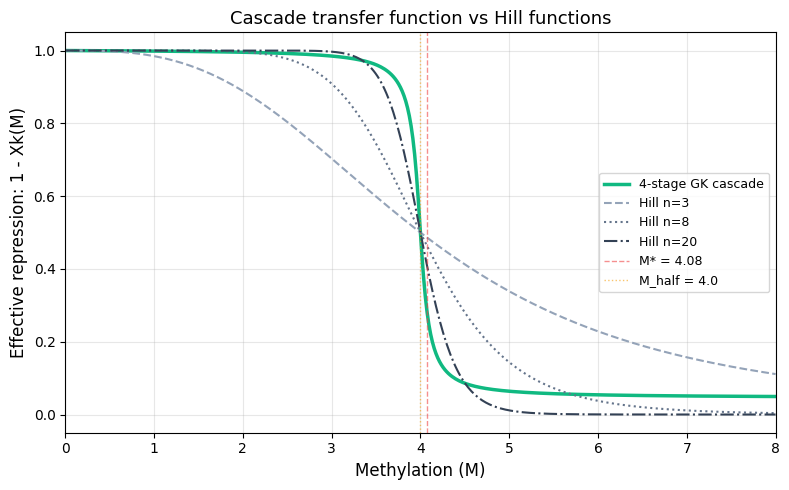

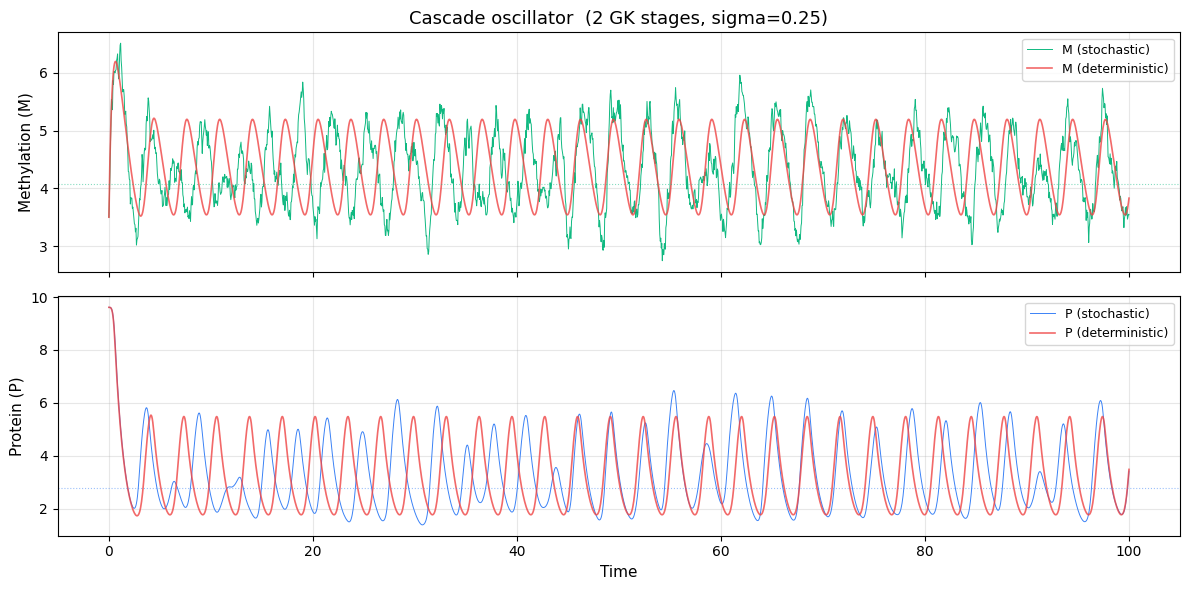

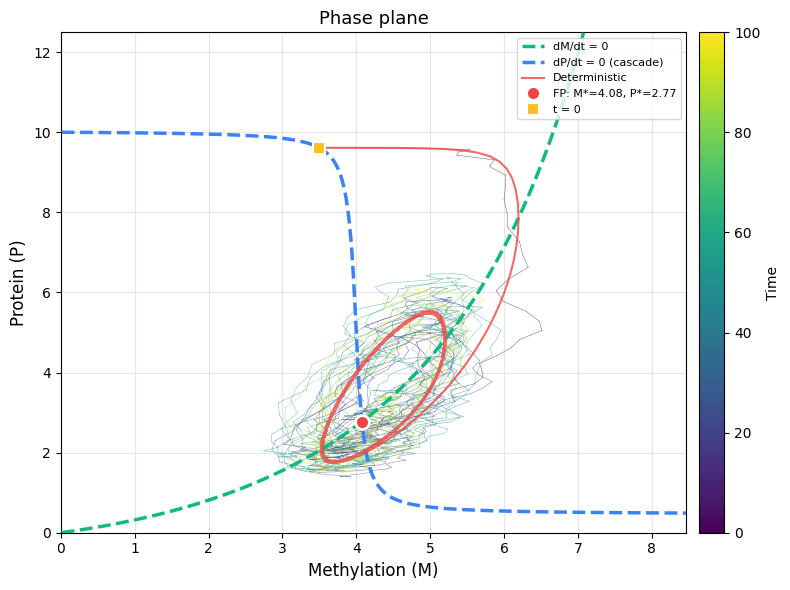

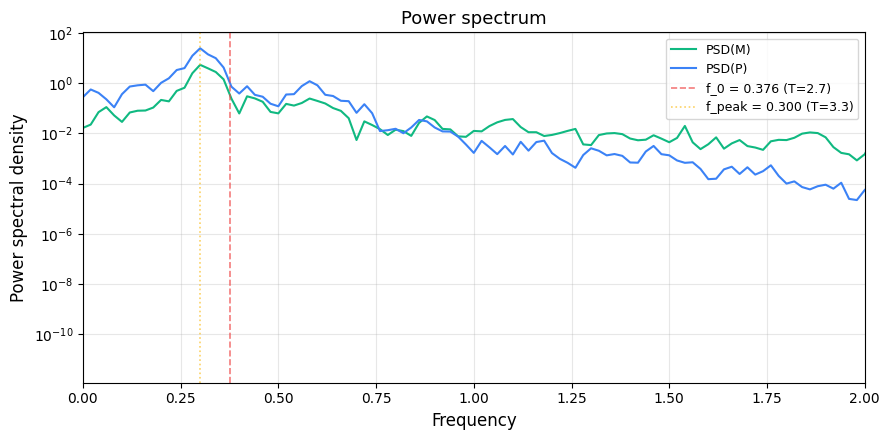


Done.


In [ ]:
# =============================================================================
# Epigenetic Oscillator with Goldbeter-Koshland Signaling Cascade
#
# The simple Hill repression is replaced by a cascade of k zero-order
# ultrasensitive (Goldbeter-Koshland) cycles:
#
#   M  -->  X1  -->  X2  -->  ...  -->  Xk  --| P
#         (GK)    (GK)              (GK)
#
# Key design: stage thresholds are MATCHED so all stages operate near
# their midpoints simultaneously. Stage 1 has Va=Vd (threshold at S=1);
# stages 2-k have Va=2*Vd (threshold at S=0.5, matching previous output).
# This gives true cascaded ultrasensitivity: n_eff ~ product of per-stage n's.
#
# References:
#   Goldbeter & Koshland (1981) PNAS 78, 6840-6844
#   Huang & Ferrell (1996) PNAS 93, 10078-10083
#   Ferrell (1996) Trends Biochem Sci 21, 460-466
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ── Parameters ───────────────────────────────────────────────────────────────

# Methylation dynamics
Mmax = 3.0
kp = 0.8
kac = 0.3
f_param = 0.1
gammaM = 1.5

# Protein
kM = 10.0

# Cascade
k_cascade = 2
tau_cascade = 5.0
Ka_base = 0.05
Kd_base = 0.05
M_half = 4.0

# Per-stage rates: stage 1 threshold at S=1, stages 2-k at S=0.5
Va_stages = np.array([1.0] + [2.0] * (k_cascade - 1))
Vd_stages = np.ones(k_cascade)
Ka_stages = np.full(k_cascade, Ka_base)
Kd_stages = np.full(k_cascade, Kd_base)

# Noise and numerics
sigma = 0.25
dt = 0.002
t_max = 100.0
seed = 2025
n_vars = k_cascade + 2


# ── Goldbeter-Koshland steady state ─────────────────────────────────────────

def gk_steady_state(S, Va, Vd, Ka, Kd):
    u = Va * max(S, 0.0)
    v = Vd
    a = v - u
    b = u * (1.0 - Kd) - v * (Ka + 1.0)
    c = u * Kd
    if abs(a) < 1e-15:
        if abs(b) < 1e-15:
            return 0.5
        x = -c / b
        return max(0.0, min(1.0, x))
    disc = max(b * b - 4.0 * a * c, 0.0)
    x1 = (-b + np.sqrt(disc)) / (2.0 * a)
    x2 = (-b - np.sqrt(disc)) / (2.0 * a)
    candidates = []
    for x in [x1, x2]:
        if -0.02 <= x <= 1.02:
            candidates.append(max(0.0, min(1.0, x)))
    if len(candidates) == 0:
        return max(0.0, min(1.0, x1))
    if len(candidates) == 1:
        return candidates[0]
    return min(candidates) if u < v else max(candidates)


def cascade_output(M_val):
    S = max(M_val, 0.0) / M_half
    for i in range(k_cascade):
        S = gk_steady_state(S, Va_stages[i], Vd_stages[i],
                            Ka_stages[i], Kd_stages[i])
    return S


# ── Dynamics ─────────────────────────────────────────────────────────────────

def rhs(state):
    M = max(state[0], 0.0)
    P = max(state[-1], 0.0)
    X = state[1:-1]

    sub = max(1.0 - f_param * M, 0.0)
    rate_M = Mmax * (kp * P + kac * M) * sub
    dM = rate_M - gammaM * M

    dX = np.zeros(k_cascade)
    S = M / M_half
    for i in range(k_cascade):
        xi = max(0.0, min(1.0, X[i]))
        denom_a = Ka_stages[i] + max(1.0 - xi, 1e-8)
        denom_d = Kd_stages[i] + max(xi, 1e-8)
        act = Va_stages[i] * max(S, 0.0) * (1.0 - xi) / denom_a
        deact = Vd_stages[i] * xi / denom_d
        dX[i] = tau_cascade * (act - deact)
        S = xi

    xk = max(0.0, min(1.0, X[-1]))
    dP = kM * (1.0 - xk) - P

    deriv = np.zeros(n_vars)
    deriv[0] = dM
    deriv[1:-1] = dX
    deriv[-1] = dP
    return deriv, rate_M


def simulate(sigma_run, rng=None):
    if rng is None:
        rng = np.random.default_rng(seed)

    sqrt_dt = np.sqrt(dt)
    n_steps = int(round(t_max / dt))
    sample_every = max(1, int(round(0.05 / dt)))
    n_samples = n_steps // sample_every + 1

    M0 = 3.5
    X0 = np.zeros(k_cascade)
    S = M0 / M_half
    for i in range(k_cascade):
        X0[i] = gk_steady_state(S, Va_stages[i], Vd_stages[i],
                                 Ka_stages[i], Kd_stages[i])
        S = X0[i]
    P0 = kM * (1.0 - X0[-1])

    state = np.zeros(n_vars)
    state[0] = M0
    state[1:-1] = X0
    state[-1] = P0

    t_out = np.empty(n_samples)
    M_out = np.empty(n_samples)
    P_out = np.empty(n_samples)
    X_all = np.empty((n_samples, k_cascade))
    idx = 0

    for i in range(n_steps + 1):
        if i % sample_every == 0 and idx < n_samples:
            t_out[idx] = i * dt
            M_out[idx] = state[0]
            P_out[idx] = state[-1]
            X_all[idx] = state[1:-1]
            idx += 1

        deriv, rate_M = rhs(state)
        if sigma_run == 0:
            state += deriv * dt
        else:
            dW = rng.standard_normal() * sqrt_dt
            state += deriv * dt
            state[0] += sigma_run * np.sqrt(max(rate_M, 0.0)) * dW
        state[0] = max(state[0], 0.0)
        state[-1] = max(state[-1], 0.0)
        state[1:-1] = np.clip(state[1:-1], 0.0, 1.0)

    return t_out[:idx], M_out[:idx], P_out[:idx], X_all[:idx]


# ── Fixed point ──────────────────────────────────────────────────────────────

def find_fixed_point():
    M = 2.0
    for _ in range(50000):
        xk = cascade_output(M)
        P = kM * (1.0 - xk)
        sub = max(1.0 - f_param * M, 0.001)
        rate = Mmax * (kp * P + kac * M) * sub
        M_new = rate / gammaM
        M = M + 0.001 * (M_new - M)
        if abs(M_new - M) < 1e-12:
            break
    return max(M, 0.0), kM * (1.0 - cascade_output(max(M, 0.0)))


def numerical_jacobian(state, eps=1e-7):
    nn = len(state)
    J = np.zeros((nn, nn))
    f0, _ = rhs(state)
    for j in range(nn):
        sp = state.copy()
        sp[j] += eps
        fp, _ = rhs(sp)
        J[:, j] = (fp - f0) / eps
    return J


def compute_nullclines(m_range, n_pts=500):
    m_vals = np.linspace(m_range[0], m_range[1], n_pts)
    sub = np.maximum(1.0 - f_param * m_vals, 1e-6)
    M_null_P = (gammaM * m_vals / (Mmax * sub) - kac * m_vals) / kp
    P_null_cascade = np.array([kM * (1.0 - cascade_output(m)) for m in m_vals])
    P_null_hill = kM / (1.0 + (m_vals / M_half) ** 3)
    return m_vals, M_null_P, P_null_cascade, P_null_hill


# =============================================================================
# RUN
# =============================================================================

rng = np.random.default_rng(seed)

# Transfer function
print("Computing cascade transfer function...")
m_test = np.linspace(0.01, 8.0, 400)
xk_test = np.array([cascade_output(m) for m in m_test])
repression_cascade = 1.0 - xk_test

print("\nCascade stage outputs at M = M_half = {:.1f}:".format(M_half))
S = 1.0
for i in range(k_cascade):
    xi = gk_steady_state(S, Va_stages[i], Vd_stages[i], Ka_stages[i], Kd_stages[i])
    print("  Stage {}: input = {:.4f},  output = {:.4f},  threshold = {:.2f}".format(
        i+1, S, xi, Vd_stages[i]/Va_stages[i]))
    S = xi

print("\nFinding fixed point...")
Mstar, Pstar = find_fixed_point()
Xk_star = cascade_output(Mstar)

state_fp = np.zeros(n_vars)
state_fp[0] = Mstar
state_fp[-1] = Pstar
S = Mstar / M_half
for i in range(k_cascade):
    state_fp[1+i] = gk_steady_state(S, Va_stages[i], Vd_stages[i],
                                      Ka_stages[i], Kd_stages[i])
    S = state_fp[1+i]

print("Computing {0}x{0} Jacobian...".format(n_vars))
J_full = numerical_jacobian(state_fp)
eigvals = np.linalg.eigvals(J_full)
eigvals_sorted = sorted(eigvals, key=lambda x: -x.real)

print("Running stochastic simulation (t_max={})...".format(t_max))
t, M_traj, P_traj, X_traj = simulate(sigma, rng)

print("Running deterministic simulation...")
t_det, M_det, P_det, X_det = simulate(0.0)


# ── Stability analysis ──────────────────────────────────────────────────────

print("")
print("=" * 65)
print("STABILITY: {} GK STAGES".format(k_cascade))
print("=" * 65)
print("")
print("Fixed point:")
print("  M*  = {:.4f}  (M*/M_half = {:.3f})".format(Mstar, Mstar/M_half))
print("  P*  = {:.4f}".format(Pstar))
print("  Xk* = {:.4f}".format(Xk_star))
print("")

labels = ["M"] + ["X{}".format(i+1) for i in range(k_cascade)] + ["P"]
print("Jacobian:")
print("       " + "  ".join(["{:>8s}".format(l) for l in labels]))
for row in range(n_vars):
    vals = "  ".join(["{:+8.3f}".format(J_full[row, col]) for col in range(n_vars)])
    print("  {}  {}".format(labels[row], vals))

print("")
print("Eigenvalues:")
shown = set()
for lam in eigvals_sorted:
    key = (round(lam.real, 3), round(abs(lam.imag), 3))
    if key in shown:
        continue
    shown.add(key)
    if abs(lam.imag) < 1e-6:
        print("  {:.4f}  (real)".format(lam.real))
    else:
        print("  {:.4f} +/- {:.4f}i".format(lam.real, abs(lam.imag)))

dom = eigvals_sorted[0]
stable = all(lam.real < 0 for lam in eigvals)
if abs(dom.imag) > 1e-6:
    omega = abs(dom.imag)
    T0 = 2 * np.pi / omega
    Q = omega / (2 * abs(dom.real))
    print("\nDominant: omega={:.4f}, T={:.2f}, Q={:.2f}".format(omega, T0, Q))

kind = "UNSTABLE SPIRAL -> LIMIT CYCLE" if (not stable and abs(dom.imag)>1e-6) \
    else "STABLE SPIRAL" if (stable and abs(dom.imag)>1e-6) \
    else "STABLE NODE" if stable else "UNSTABLE"
print("Classification: {}".format(kind))
print("=" * 65)


# ── Plot 1: Transfer function ────────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(m_test, repression_cascade, color="#10b981", lw=2.5,
         label="4-stage GK cascade")
ax1.plot(m_test, 1.0/(1+(m_test/M_half)**3), color="#94a3b8", lw=1.5, ls="--",
         label="Hill n=3")
ax1.plot(m_test, 1.0/(1+(m_test/M_half)**8), color="#64748b", lw=1.5, ls=":",
         label="Hill n=8")
ax1.plot(m_test, 1.0/(1+(m_test/M_half)**20), color="#334155", lw=1.5, ls="-.",
         label="Hill n=20")
ax1.axvline(Mstar, color="#ef4444", ls="--", lw=1, alpha=0.6,
            label="M* = {:.2f}".format(Mstar))
ax1.axvline(M_half, color="#f59e0b", ls=":", lw=1, alpha=0.6,
            label="M_half = {:.1f}".format(M_half))
ax1.set_xlabel("Methylation (M)", fontsize=12)
ax1.set_ylabel("Effective repression: 1 - Xk(M)", fontsize=12)
ax1.set_title("Cascade transfer function vs Hill functions", fontsize=13)
ax1.legend(loc="center right", fontsize=9)
ax1.set_xlim(0, 8)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cascade_transfer.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 2: Time series ─────────────────────────────────────────────────────

fig2, (ax2a, ax2b) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax2a.plot(t, M_traj, color="#10b981", lw=0.7, label="M (stochastic)")
ax2a.plot(t_det, M_det, color="#ef4444", lw=1.2, alpha=0.8, label="M (deterministic)")
ax2a.axhline(Mstar, color="#10b981", ls=":", lw=0.8, alpha=0.5)
ax2a.set_ylabel("Methylation (M)", fontsize=11)
ax2a.set_title("Cascade oscillator  ({} GK stages, sigma={})".format(k_cascade, sigma), fontsize=13)
ax2a.legend(loc="upper right", fontsize=9)
ax2a.grid(True, alpha=0.3)

ax2b.plot(t, P_traj, color="#3b82f6", lw=0.7, label="P (stochastic)")
ax2b.plot(t_det, P_det, color="#ef4444", lw=1.2, alpha=0.8, label="P (deterministic)")
ax2b.axhline(Pstar, color="#3b82f6", ls=":", lw=0.8, alpha=0.5)
ax2b.set_xlabel("Time", fontsize=11)
ax2b.set_ylabel("Protein (P)", fontsize=11)
ax2b.legend(loc="upper right", fontsize=9)
ax2b.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cascade_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 3: Phase plane ─────────────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 6))
m_upper = min(1.0/f_param*0.95, max(np.max(M_traj), np.max(M_det))*1.3)
m_nc, M_null_P, P_null_cascade, P_null_hill = compute_nullclines((0.01, m_upper))

p_plot_max = max(np.max(P_traj)*1.3, Pstar*2.5, kM*1.05)
mask = (M_null_P > -0.3) & (M_null_P < p_plot_max)
ax3.plot(m_nc[mask], M_null_P[mask], color="#10b981", lw=2.5, ls="--",
         label="dM/dt = 0", zorder=5)
ax3.plot(m_nc, P_null_cascade, color="#3b82f6", lw=2.5, ls="--",
         label="dP/dt = 0 (cascade)", zorder=5)
#ax3.plot(m_nc, P_null_hill, color="#94a3b8", lw=1.5, ls=":",
     #    label="dP/dt = 0 (Hill n=3)", zorder=4, alpha=0.6)

n_pts = len(M_traj)
colors = plt.cm.viridis(np.linspace(0, 1, n_pts))
for i in range(n_pts - 1):
    ax3.plot(M_traj[i:i+2], P_traj[i:i+2], color=colors[i], lw=0.4, alpha=0.6)
ax3.plot(M_det, P_det, color="#ef4444", lw=1.5, alpha=0.8,
         label="Deterministic", zorder=6)

fp_color = "#10b981" if stable else "#ef4444"
ax3.plot(Mstar, Pstar, "o", color=fp_color, ms=10, mew=2, mec="white",
         zorder=12, label="FP: M*={:.2f}, P*={:.2f}".format(Mstar, Pstar))
ax3.plot(M_traj[0], P_traj[0], "s", color="#fbbf24", ms=8, mew=1.5,
         mec="white", zorder=11, label="t = 0")

sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, t_max))
sm.set_array([])
plt.colorbar(sm, ax=ax3, pad=0.02, fraction=0.04).set_label("Time", fontsize=10)
ax3.set_xlabel("Methylation (M)", fontsize=12)
ax3.set_ylabel("Protein (P)", fontsize=12)
ax3.set_title("Phase plane", fontsize=13)
ax3.legend(loc="upper right", fontsize=8)
ax3.set_xlim(0, m_upper)
ax3.set_ylim(bottom=0, top=p_plot_max)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cascade_phaseplane.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 4: Power spectrum ───────────────────────────────────────────────────

fig4, ax4 = plt.subplots(figsize=(9, 4.5))
dt_s = t[1] - t[0]
nperseg = min(1024, len(M_traj)//2)
freqs_M, psd_M = welch(M_traj-np.mean(M_traj), fs=1.0/dt_s,
                        nperseg=nperseg, detrend="linear", window="hann")
freqs_P, psd_P = welch(P_traj-np.mean(P_traj), fs=1.0/dt_s,
                        nperseg=nperseg, detrend="linear", window="hann")
ax4.semilogy(freqs_M, psd_M, color="#10b981", lw=1.5, label="PSD(M)")
ax4.semilogy(freqs_P, psd_P, color="#3b82f6", lw=1.5, label="PSD(P)")

if abs(dom.imag) > 1e-6:
    f_0 = abs(dom.imag) / (2*np.pi)
    ax4.axvline(f_0, color="#ef4444", ls="--", lw=1.2, alpha=0.7,
                label="f_0 = {:.3f} (T={:.1f})".format(f_0, 1.0/f_0))
freq_mask = freqs_M > 0.005
if np.any(freq_mask):
    pk = np.argmax(psd_M[freq_mask])
    f_pk = freqs_M[freq_mask][pk]
    if f_pk > 0:
        ax4.axvline(f_pk, color="#fbbf24", ls=":", lw=1.2, alpha=0.7,
                    label="f_peak = {:.3f} (T={:.1f})".format(f_pk, 1.0/f_pk))
ax4.set_xlabel("Frequency", fontsize=12)
ax4.set_ylabel("Power spectral density", fontsize=12)
ax4.set_title("Power spectrum", fontsize=13)
ax4.set_xlim(0, 2.0)
ax4.legend(loc="upper right", fontsize=9)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cascade_psd.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDone.")

Computing cascade transfer function (P -> Xk)...

Cascade stage outputs at P = P_half = 1.5:
  Stage 1: input = 1.0000,  output = 0.5000

Finding fixed point...
Computing 3x3 Jacobian...
Running stochastic simulation (sigma=0.25)...
Running deterministic simulation...

ARCHITECTURE 2: CASCADE ON DRIVE ARM (1 GK stages)
  P --cascade--> Xk --> M --Hill--| P

Parameters:
  kp=3.0, kac=0.3, Mmax=4.0, f=0.1, gammaM=1.5
  kM=3.0, n_hill=4.0, K_rep=3.5
  P_half=1.5, tau=5.0, Ka=0.05, Kd=0.05

Fixed point:
  M*  = 3.6069
  P*  = 1.4098  (P*/P_half = 0.940)
  Xk* = 0.3445  (cascade output at FP)

Jacobian:
              M        X1         P
  M    -1.579    +7.672    +0.000
  X1    +0.000    -2.078    +3.097
  P    -0.829    +0.000    -1.000

Eigenvalues:
  -0.1845 +/- 2.3071i
  -4.2883  (real)

Dominant: omega=2.3071, T=2.72, Q=6.25
Classification: STABLE SPIRAL


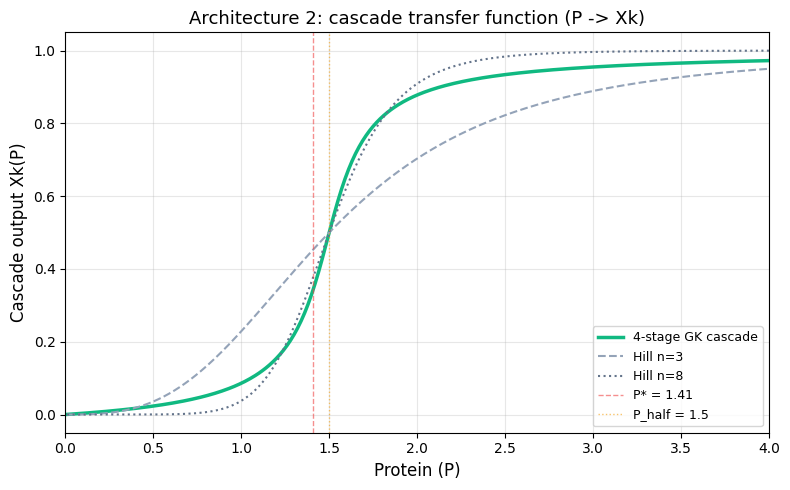

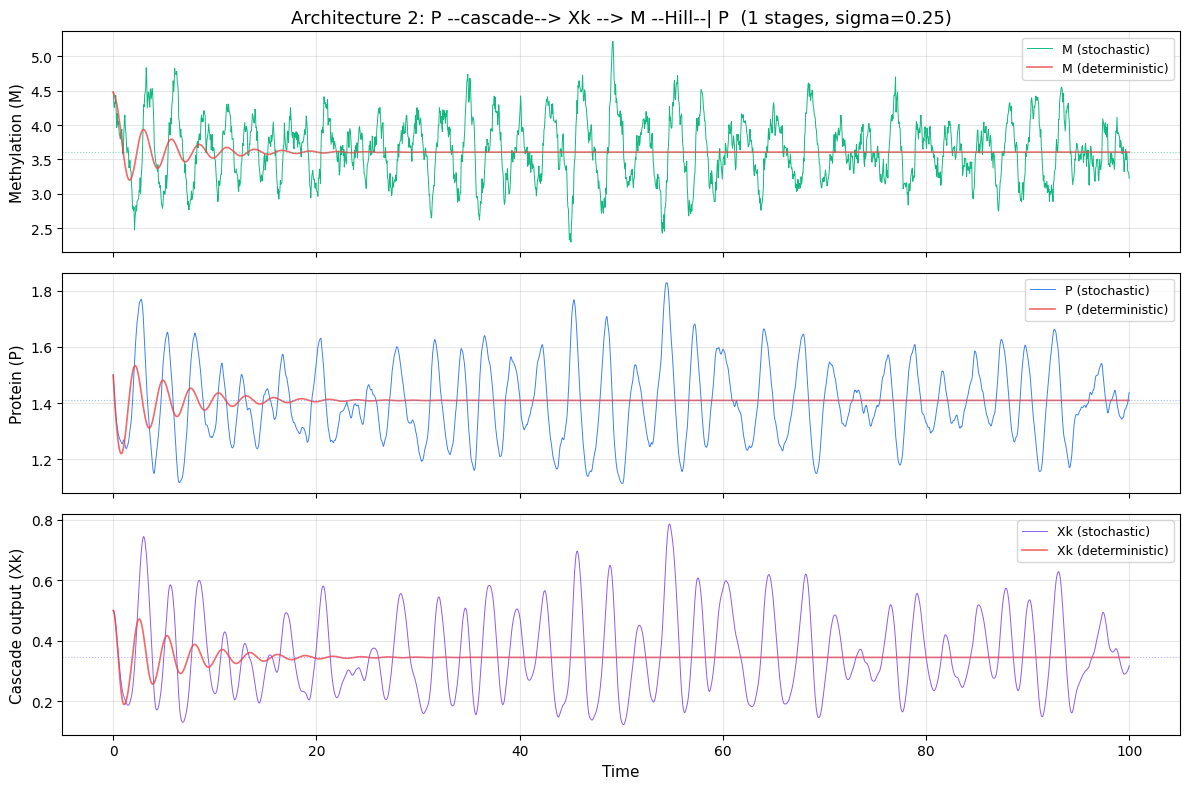

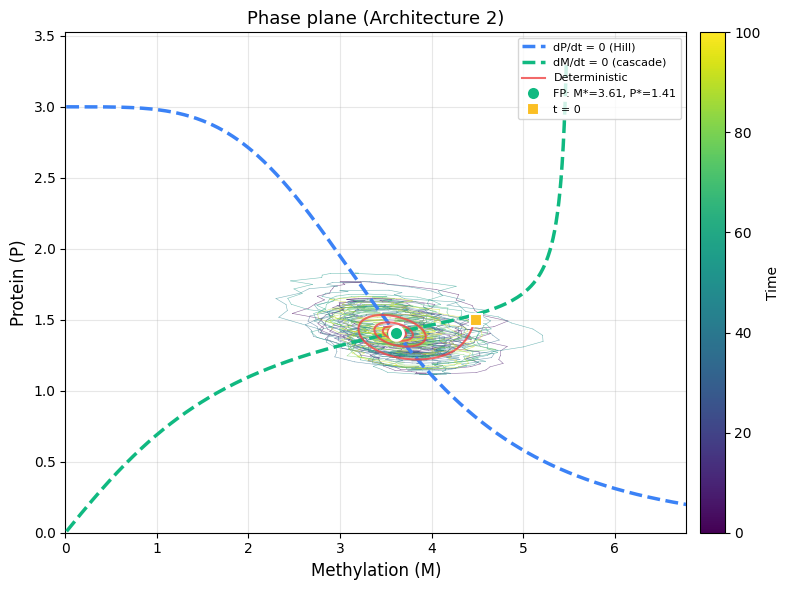

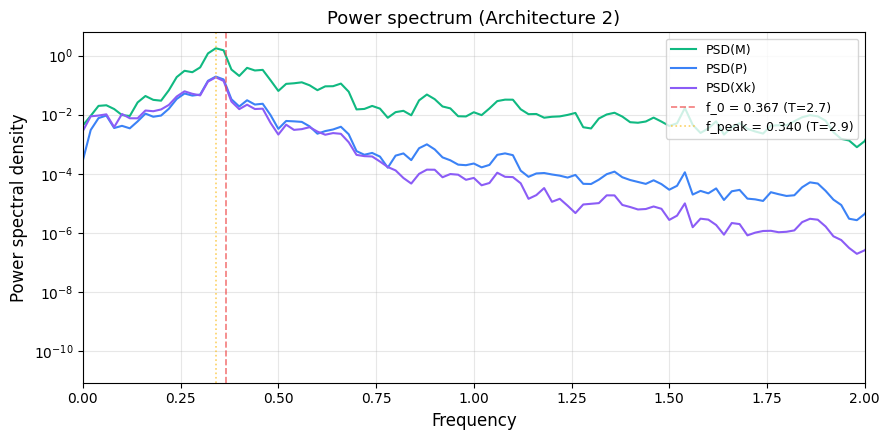

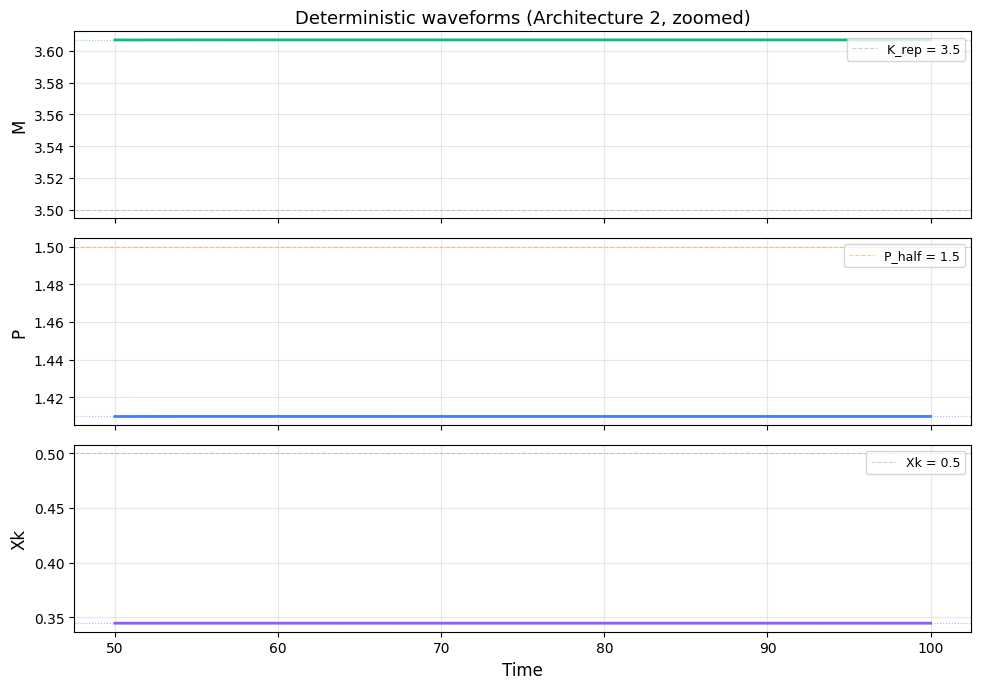


Done.


In [ ]:
# =============================================================================
# Architecture 2: Cascade on the Drive Arm
#
# The cascade converts PROTEIN level into a methylation-driving signal,
# while methylation directly represses protein via a Hill function.
#
#   P  -->  X1  -->  X2  -->  ...  -->  Xk  -->  M  --| P
#         (GK)    (GK)              (GK)          (Hill)
#
# Equations:
#   dX_i/dt = tau * [Va^(i) S_{i-1} (1-X_i)/(Ka^(i)+1-X_i)
#                    - Vd^(i) X_i/(Kd^(i)+X_i)]
#     where S_0 = P/P_half, S_i = X_i for i >= 1
#
#   dM = [Mmax*(kp*Xk + kac*M)*(1-fM) - gammaM*M] dt
#        + sigma*sqrt(rate)*dW
#
#   dP/dt = kM / (1 + (M/K_rep)^n) - P
#
# Compare with Architecture 1 (cascade on repression arm):
#   P --kp--> M --cascade--> Xk --| P
#
# References:
#   Goldbeter & Koshland (1981) PNAS 78, 6840-6844
#   Tyson et al. (2003) Curr Opin Cell Biol 15, 221-231
#   Dodd et al. (2007) Cell 129, 813-822
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ── Parameters ───────────────────────────────────────────────────────────────

# Methylation dynamics
Mmax = 4.0
kp = 3.0           # gain from cascade output Xk to methylation
kac = 0.3           # autocatalytic reader-writer rate
f_param = 0.1       # substrate saturation (1/f = 10)
gammaM = 1.5

# Protein (repressed directly by M via Hill)
kM = 3.0
n_hill = 4.0        # Hill coefficient for direct repression
K_rep = 3.5          # repression midpoint

# Cascade (on the DRIVE arm: P -> X1 -> ... -> Xk -> M)
k_cascade = 1
tau_cascade = 5.0
Ka_base = 0.05
Kd_base = 0.05
P_half = 1.5         # input normalization for protein

# Stage threshold matching (same principle as architecture 1)
Va_stages = np.array([1.0] + [2.0] * (k_cascade - 1))
Vd_stages = np.ones(k_cascade)
Ka_stages = np.full(k_cascade, Ka_base)
Kd_stages = np.full(k_cascade, Kd_base)

# Noise and numerics
sigma = 0.25
dt = 0.002
t_max = 100.0
seed = 2025

# State vector: [M, X_1, ..., X_k, P]
n_vars = k_cascade + 2


# ── Goldbeter-Koshland steady state ─────────────────────────────────────────

def gk_steady_state(S, Va, Vd, Ka, Kd):
    u = Va * max(S, 0.0)
    v = Vd
    a = v - u
    b = u * (1.0 - Kd) - v * (Ka + 1.0)
    c = u * Kd
    if abs(a) < 1e-15:
        if abs(b) < 1e-15:
            return 0.5
        x = -c / b
        return max(0.0, min(1.0, x))
    disc = max(b * b - 4.0 * a * c, 0.0)
    x1 = (-b + np.sqrt(disc)) / (2.0 * a)
    x2 = (-b - np.sqrt(disc)) / (2.0 * a)
    candidates = []
    for x in [x1, x2]:
        if -0.02 <= x <= 1.02:
            candidates.append(max(0.0, min(1.0, x)))
    if len(candidates) == 0:
        return max(0.0, min(1.0, x1))
    if len(candidates) == 1:
        return candidates[0]
    return min(candidates) if u < v else max(candidates)


def cascade_output(P_val):
    # Cascade steady-state output given protein level P.
    S = max(P_val, 0.0) / P_half
    for i in range(k_cascade):
        S = gk_steady_state(S, Va_stages[i], Vd_stages[i],
                            Ka_stages[i], Kd_stages[i])
    return S


# ── Dynamics ─────────────────────────────────────────────────────────────────

def rhs(state):
    # State = [M, X_1, ..., X_k, P]
    M = max(state[0], 0.0)
    P = max(state[-1], 0.0)
    X = state[1:-1]

    # Cascade: driven by PROTEIN
    dX = np.zeros(k_cascade)
    S = P / P_half  # protein is the cascade input
    for i in range(k_cascade):
        xi = max(0.0, min(1.0, X[i]))
        denom_a = Ka_stages[i] + max(1.0 - xi, 1e-8)
        denom_d = Kd_stages[i] + max(xi, 1e-8)
        act = Va_stages[i] * max(S, 0.0) * (1.0 - xi) / denom_a
        deact = Vd_stages[i] * xi / denom_d
        dX[i] = tau_cascade * (act - deact)
        S = xi

    # Methylation: driven by cascade output Xk + autocatalysis
    xk = max(0.0, min(1.0, X[-1]))
    sub = max(1.0 - f_param * M, 0.0)
    rate_M = Mmax * (kp * xk + kac * M) * sub
    dM = rate_M - gammaM * M

    # Protein: repressed directly by M via Hill function
    hill = kM / (1.0 + (M / K_rep) ** n_hill)
    dP = hill - P

    deriv = np.zeros(n_vars)
    deriv[0] = dM
    deriv[1:-1] = dX
    deriv[-1] = dP
    return deriv, rate_M


# ── Simulation ───────────────────────────────────────────────────────────────

def simulate(sigma_run, rng=None):
    if rng is None:
        rng = np.random.default_rng(seed)

    sqrt_dt = np.sqrt(dt)
    n_steps = int(round(t_max / dt))
    sample_every = max(1, int(round(0.05 / dt)))
    n_samples = n_steps // sample_every + 1

    # Initial condition: estimate from cascade steady state
    P0 = 1.5
    X0 = np.zeros(k_cascade)
    S = P0 / P_half
    for i in range(k_cascade):
        X0[i] = gk_steady_state(S, Va_stages[i], Vd_stages[i],
                                 Ka_stages[i], Kd_stages[i])
        S = X0[i]
    xk0 = X0[-1]
    # Rough M estimate: rate/gammaM
    M0 = Mmax * (kp * xk0 + kac * 2.0) * (1.0 - f_param * 2.0) / gammaM
    M0 = max(M0, 1.0)

    state = np.zeros(n_vars)
    state[0] = M0
    state[1:-1] = X0
    state[-1] = P0

    t_out = np.empty(n_samples)
    M_out = np.empty(n_samples)
    P_out = np.empty(n_samples)
    Xk_out = np.empty(n_samples)
    idx = 0

    for i in range(n_steps + 1):
        if i % sample_every == 0 and idx < n_samples:
            t_out[idx] = i * dt
            M_out[idx] = state[0]
            P_out[idx] = state[-1]
            Xk_out[idx] = state[k_cascade]  # last cascade stage
            idx += 1

        deriv, rate_M = rhs(state)
        if sigma_run == 0:
            state += deriv * dt
        else:
            dW = rng.standard_normal() * sqrt_dt
            state += deriv * dt
            state[0] += sigma_run * np.sqrt(max(rate_M, 0.0)) * dW
        state[0] = max(state[0], 0.0)
        state[-1] = max(state[-1], 0.0)
        state[1:-1] = np.clip(state[1:-1], 0.0, 1.0)

    return t_out[:idx], M_out[:idx], P_out[:idx], Xk_out[:idx]


# ── Fixed point ──────────────────────────────────────────────────────────────

def find_fixed_point():
    # Self-consistent iteration: P -> cascade -> Xk -> M -> Hill -> P
    P = 1.5
    for _ in range(50000):
        xk = cascade_output(P)
        # M from dM/dt = 0: Mmax*(kp*Xk + kac*M)*(1-fM) = gammaM*M
        # Iterate for M given Xk
        M = 2.0
        for _ in range(5000):
            sub = max(1.0 - f_param * M, 0.001)
            rate = Mmax * (kp * xk + kac * M) * sub
            M_new = rate / gammaM
            M = M + 0.01 * (M_new - M)
            if abs(M_new - M) < 1e-13:
                break
        P_new = kM / (1.0 + (M / K_rep) ** n_hill)
        err = P_new - P
        P = P + 0.002 * err
        if abs(err) < 1e-12:
            break
    xk = cascade_output(P)
    # Final M
    M = 2.0
    for _ in range(5000):
        sub = max(1.0 - f_param * M, 0.001)
        rate = Mmax * (kp * xk + kac * M) * sub
        M_new = rate / gammaM
        M = M + 0.01 * (M_new - M)
        if abs(M_new - M) < 1e-13:
            break
    return max(M, 0.0), max(P, 0.0)


def numerical_jacobian(state, eps=1e-7):
    nn = len(state)
    J = np.zeros((nn, nn))
    f0, _ = rhs(state)
    for j in range(nn):
        sp = state.copy()
        sp[j] += eps
        fp, _ = rhs(sp)
        J[:, j] = (fp - f0) / eps
    return J


# ── Nullclines in (M, P) plane ──────────────────────────────────────────────

def compute_nullclines(m_range, n_pts=500):
    m_vals = np.linspace(m_range[0], m_range[1], n_pts)

    # P-nullcline (direct Hill repression): P = kM / (1 + (M/K_rep)^n)
    P_null = kM / (1.0 + (m_vals / K_rep) ** n_hill)

    # M-nullcline: Mmax*(kp*Xk(P) + kac*M)*(1-fM) = gammaM*M
    # This depends on P through the cascade, so we need to solve for P(M)
    # From M-nullcline: kp*Xk(P) = gammaM*M / (Mmax*(1-fM)) - kac*M
    # Then Xk(P) is known -> invert cascade to get P
    # Easier: parametrize by P, compute M for each P
    p_vals = np.linspace(0.01, kM * 1.1, n_pts)
    M_null_m = np.zeros(n_pts)
    for j, p in enumerate(p_vals):
        xk = cascade_output(p)
        # Solve: Mmax*(kp*xk + kac*M)*(1-fM) = gammaM*M for M
        M = 1.0
        for _ in range(3000):
            sub = max(1.0 - f_param * M, 0.001)
            rate = Mmax * (kp * xk + kac * M) * sub
            M_new = rate / gammaM
            M = M + 0.01 * (M_new - M)
            if abs(M_new - M) < 1e-12:
                break
        M_null_m[j] = max(M, 0.0)

    return m_vals, P_null, M_null_m, p_vals


# =============================================================================
# RUN
# =============================================================================

rng = np.random.default_rng(seed)

# Transfer function: cascade output vs protein level
print("Computing cascade transfer function (P -> Xk)...")
p_test = np.linspace(0.01, 4.0, 400)
xk_test = np.array([cascade_output(p) for p in p_test])

# Verify stage matching at P = P_half
print("\nCascade stage outputs at P = P_half = {:.1f}:".format(P_half))
S = 1.0
for i in range(k_cascade):
    xi = gk_steady_state(S, Va_stages[i], Vd_stages[i], Ka_stages[i], Kd_stages[i])
    print("  Stage {}: input = {:.4f},  output = {:.4f}".format(i+1, S, xi))
    S = xi

# Fixed point
print("\nFinding fixed point...")
Mstar, Pstar = find_fixed_point()
Xk_star = cascade_output(Pstar)

# Full state at FP
state_fp = np.zeros(n_vars)
state_fp[0] = Mstar
state_fp[-1] = Pstar
S = Pstar / P_half
for i in range(k_cascade):
    state_fp[1+i] = gk_steady_state(S, Va_stages[i], Vd_stages[i],
                                      Ka_stages[i], Kd_stages[i])
    S = state_fp[1+i]

# Jacobian
print("Computing {0}x{0} Jacobian...".format(n_vars))
J_full = numerical_jacobian(state_fp)
eigvals = np.linalg.eigvals(J_full)
eigvals_sorted = sorted(eigvals, key=lambda x: -x.real)

# Simulations
print("Running stochastic simulation (sigma={})...".format(sigma))
t, M_traj, P_traj, Xk_traj = simulate(sigma, rng)

print("Running deterministic simulation...")
t_det, M_det, P_det, Xk_det = simulate(0.0)


# ── Stability analysis ──────────────────────────────────────────────────────

print("")
print("=" * 65)
print("ARCHITECTURE 2: CASCADE ON DRIVE ARM ({} GK stages)".format(k_cascade))
print("  P --cascade--> Xk --> M --Hill--| P")
print("=" * 65)
print("")
print("Parameters:")
print("  kp={}, kac={}, Mmax={}, f={}, gammaM={}".format(kp, kac, Mmax, f_param, gammaM))
print("  kM={}, n_hill={}, K_rep={}".format(kM, n_hill, K_rep))
print("  P_half={}, tau={}, Ka={}, Kd={}".format(P_half, tau_cascade, Ka_base, Kd_base))
print("")
print("Fixed point:")
print("  M*  = {:.4f}".format(Mstar))
print("  P*  = {:.4f}  (P*/P_half = {:.3f})".format(Pstar, Pstar/P_half))
print("  Xk* = {:.4f}  (cascade output at FP)".format(Xk_star))
print("")

labels = ["M"] + ["X{}".format(i+1) for i in range(k_cascade)] + ["P"]
print("Jacobian:")
print("       " + "  ".join(["{:>8s}".format(l) for l in labels]))
for row in range(n_vars):
    vals = "  ".join(["{:+8.3f}".format(J_full[row, col]) for col in range(n_vars)])
    print("  {}  {}".format(labels[row], vals))

print("")
print("Eigenvalues:")
shown = set()
for lam in eigvals_sorted:
    key = (round(lam.real, 3), round(abs(lam.imag), 3))
    if key in shown:
        continue
    shown.add(key)
    if abs(lam.imag) < 1e-6:
        print("  {:.4f}  (real)".format(lam.real))
    else:
        print("  {:.4f} +/- {:.4f}i".format(lam.real, abs(lam.imag)))

dom = eigvals_sorted[0]
stable = all(lam.real < 0 for lam in eigvals)
if abs(dom.imag) > 1e-6:
    omega = abs(dom.imag)
    T0 = 2 * np.pi / omega
    Q = omega / (2 * abs(dom.real))
    print("\nDominant: omega={:.4f}, T={:.2f}, Q={:.2f}".format(omega, T0, Q))

kind = "UNSTABLE SPIRAL -> LIMIT CYCLE" if (not stable and abs(dom.imag)>1e-6) \
    else "STABLE SPIRAL" if (stable and abs(dom.imag)>1e-6) \
    else "STABLE NODE" if stable else "UNSTABLE"
print("Classification: {}".format(kind))
print("=" * 65)


# ── Plot 1: Transfer function ────────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(p_test, xk_test, color="#10b981", lw=2.5,
         label="4-stage GK cascade")
ax1.plot(p_test, (p_test/P_half)**3 / (1+(p_test/P_half)**3),
         color="#94a3b8", lw=1.5, ls="--", label="Hill n=3")
ax1.plot(p_test, (p_test/P_half)**8 / (1+(p_test/P_half)**8),
         color="#64748b", lw=1.5, ls=":", label="Hill n=8")
ax1.axvline(Pstar, color="#ef4444", ls="--", lw=1, alpha=0.6,
            label="P* = {:.2f}".format(Pstar))
ax1.axvline(P_half, color="#f59e0b", ls=":", lw=1, alpha=0.6,
            label="P_half = {:.1f}".format(P_half))
ax1.set_xlabel("Protein (P)", fontsize=12)
ax1.set_ylabel("Cascade output Xk(P)", fontsize=12)
ax1.set_title("Architecture 2: cascade transfer function (P -> Xk)", fontsize=13)
ax1.legend(loc="lower right", fontsize=9)
ax1.set_xlim(0, 4)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("arch2_transfer.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 2: Time series ─────────────────────────────────────────────────────

fig2, (ax2a, ax2b, ax2c) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax2a.plot(t, M_traj, color="#10b981", lw=0.7, label="M (stochastic)")
ax2a.plot(t_det, M_det, color="#ef4444", lw=1.2, alpha=0.8, label="M (deterministic)")
ax2a.axhline(Mstar, color="#10b981", ls=":", lw=0.8, alpha=0.5)
ax2a.set_ylabel("Methylation (M)", fontsize=11)
ax2a.set_title("Architecture 2: P --cascade--> Xk --> M --Hill--| P  "
               "({} stages, sigma={})".format(k_cascade, sigma), fontsize=13)
ax2a.legend(loc="upper right", fontsize=9)
ax2a.grid(True, alpha=0.3)

ax2b.plot(t, P_traj, color="#3b82f6", lw=0.7, label="P (stochastic)")
ax2b.plot(t_det, P_det, color="#ef4444", lw=1.2, alpha=0.8, label="P (deterministic)")
ax2b.axhline(Pstar, color="#3b82f6", ls=":", lw=0.8, alpha=0.5)
ax2b.set_ylabel("Protein (P)", fontsize=11)
ax2b.legend(loc="upper right", fontsize=9)
ax2b.grid(True, alpha=0.3)

ax2c.plot(t, Xk_traj, color="#8b5cf6", lw=0.7, label="Xk (stochastic)")
ax2c.plot(t_det, Xk_det, color="#ef4444", lw=1.2, alpha=0.8, label="Xk (deterministic)")
ax2c.axhline(Xk_star, color="#8b5cf6", ls=":", lw=0.8, alpha=0.5)
ax2c.set_xlabel("Time", fontsize=11)
ax2c.set_ylabel("Cascade output (Xk)", fontsize=11)
ax2c.legend(loc="upper right", fontsize=9)
ax2c.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("arch2_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 3: Phase plane (M vs P) ────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 6))

# Nullclines
m_upper = min(1.0/f_param*0.95, max(np.max(M_traj), np.max(M_det))*1.3)
m_nc, P_null, M_null_m, M_null_p = compute_nullclines((0.01, m_upper))

# P-nullcline: P = kM/(1+(M/K)^n) — plot in (M, P) plane
ax3.plot(m_nc, P_null, color="#3b82f6", lw=2.5, ls="--",
         label="dP/dt = 0 (Hill)", zorder=5)

# M-nullcline: parametric (M_null_m, M_null_p) — plot in (M, P) plane
p_plot_max = max(np.max(P_traj)*1.3, Pstar*2.5, kM*1.05)
mask = (M_null_p > 0) & (M_null_p < p_plot_max) & (M_null_m < m_upper)
ax3.plot(M_null_m[mask], M_null_p[mask], color="#10b981", lw=2.5, ls="--",
         label="dM/dt = 0 (cascade)", zorder=5)

# Trajectory
n_pts = len(M_traj)
colors = plt.cm.viridis(np.linspace(0, 1, n_pts))
for i in range(n_pts - 1):
    ax3.plot(M_traj[i:i+2], P_traj[i:i+2], color=colors[i], lw=0.4, alpha=0.6)

# Deterministic
ax3.plot(M_det, P_det, color="#ef4444", lw=1.5, alpha=0.8,
         label="Deterministic", zorder=6)

fp_color = "#10b981" if stable else "#ef4444"
ax3.plot(Mstar, Pstar, "o", color=fp_color, ms=10, mew=2, mec="white",
         zorder=12, label="FP: M*={:.2f}, P*={:.2f}".format(Mstar, Pstar))
ax3.plot(M_traj[0], P_traj[0], "s", color="#fbbf24", ms=8, mew=1.5,
         mec="white", zorder=11, label="t = 0")

sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, t_max))
sm.set_array([])
plt.colorbar(sm, ax=ax3, pad=0.02, fraction=0.04).set_label("Time", fontsize=10)
ax3.set_xlabel("Methylation (M)", fontsize=12)
ax3.set_ylabel("Protein (P)", fontsize=12)
ax3.set_title("Phase plane (Architecture 2)", fontsize=13)
ax3.legend(loc="upper right", fontsize=8)
ax3.set_xlim(0, m_upper)
ax3.set_ylim(bottom=0, top=p_plot_max)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("arch2_phaseplane.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 4: Power spectrum ───────────────────────────────────────────────────

fig4, ax4 = plt.subplots(figsize=(9, 4.5))

dt_s = t[1] - t[0]
nperseg = min(1024, len(M_traj)//2)
freqs_M, psd_M = welch(M_traj-np.mean(M_traj), fs=1.0/dt_s,
                        nperseg=nperseg, detrend="linear", window="hann")
freqs_P, psd_P = welch(P_traj-np.mean(P_traj), fs=1.0/dt_s,
                        nperseg=nperseg, detrend="linear", window="hann")
freqs_X, psd_X = welch(Xk_traj-np.mean(Xk_traj), fs=1.0/dt_s,
                        nperseg=nperseg, detrend="linear", window="hann")

ax4.semilogy(freqs_M, psd_M, color="#10b981", lw=1.5, label="PSD(M)")
ax4.semilogy(freqs_P, psd_P, color="#3b82f6", lw=1.5, label="PSD(P)")
ax4.semilogy(freqs_X, psd_X, color="#8b5cf6", lw=1.5, label="PSD(Xk)")

if abs(dom.imag) > 1e-6:
    f_0 = abs(dom.imag) / (2*np.pi)
    ax4.axvline(f_0, color="#ef4444", ls="--", lw=1.2, alpha=0.7,
                label="f_0 = {:.3f} (T={:.1f})".format(f_0, 1.0/f_0))

freq_mask = freqs_M > 0.005
if np.any(freq_mask):
    pk = np.argmax(psd_M[freq_mask])
    f_pk = freqs_M[freq_mask][pk]
    if f_pk > 0:
        ax4.axvline(f_pk, color="#fbbf24", ls=":", lw=1.2, alpha=0.7,
                    label="f_peak = {:.3f} (T={:.1f})".format(f_pk, 1.0/f_pk))

ax4.set_xlabel("Frequency", fontsize=12)
ax4.set_ylabel("Power spectral density", fontsize=12)
ax4.set_title("Power spectrum (Architecture 2)", fontsize=13)
ax4.set_xlim(0, 2.0)
ax4.legend(loc="upper right", fontsize=9)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("arch2_psd.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Plot 5: Waveform comparison (det only, zoomed) ──────────────────────────

fig5, (ax5a, ax5b, ax5c) = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# Zoom to a few cycles
t_zoom = (50, 120)
mask_det = (t_det >= t_zoom[0]) & (t_det <= t_zoom[1])

ax5a.plot(t_det[mask_det], M_det[mask_det], color="#10b981", lw=2)
ax5a.axhline(Mstar, color="#10b981", ls=":", lw=0.8, alpha=0.5)
ax5a.axhline(K_rep, color="#94a3b8", ls="--", lw=0.8, alpha=0.5,
             label="K_rep = {:.1f}".format(K_rep))
ax5a.set_ylabel("M", fontsize=12)
ax5a.set_title("Deterministic waveforms (Architecture 2, zoomed)", fontsize=13)
ax5a.legend(loc="upper right", fontsize=9)
ax5a.grid(True, alpha=0.3)

ax5b.plot(t_det[mask_det], P_det[mask_det], color="#3b82f6", lw=2)
ax5b.axhline(Pstar, color="#3b82f6", ls=":", lw=0.8, alpha=0.5)
ax5b.axhline(P_half, color="#f59e0b", ls="--", lw=0.8, alpha=0.5,
             label="P_half = {:.1f}".format(P_half))
ax5b.set_ylabel("P", fontsize=12)
ax5b.legend(loc="upper right", fontsize=9)
ax5b.grid(True, alpha=0.3)

ax5c.plot(t_det[mask_det], Xk_det[mask_det], color="#8b5cf6", lw=2)
ax5c.axhline(Xk_star, color="#8b5cf6", ls=":", lw=0.8, alpha=0.5)
ax5c.axhline(0.5, color="#94a3b8", ls="--", lw=0.8, alpha=0.5, label="Xk = 0.5")
ax5c.set_xlabel("Time", fontsize=12)
ax5c.set_ylabel("Xk", fontsize=12)
ax5c.legend(loc="upper right", fontsize=9)
ax5c.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("arch2_waveform.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDone.")

k=1  ARCHITECTURE 2  with autocatalysis  (k_ac = 0.3)
  P –GK–> X –> M –Hill–| P

Fixed point:  M* = 6.5141   X* = 0.5562   P* = 1.6741

Jacobian:
  M    -2.831    +16.183     +0.000
  X    +0.000     -0.320     +2.347
  P    -0.598     +0.000     -1.000

Eigenvalues:
  +0.1427 +/- 2.3026i
  +0.1427 +/- 2.3026i
  -4.4361

Classification:  UNSTABLE SPIRAL -> LIMIT CYCLE
Linearised period:  T_0 = 2.73

Running deterministic simulation...
Running stochastic simulation (sigma = 0.15)...
Measured deterministic period:  T = 2.78


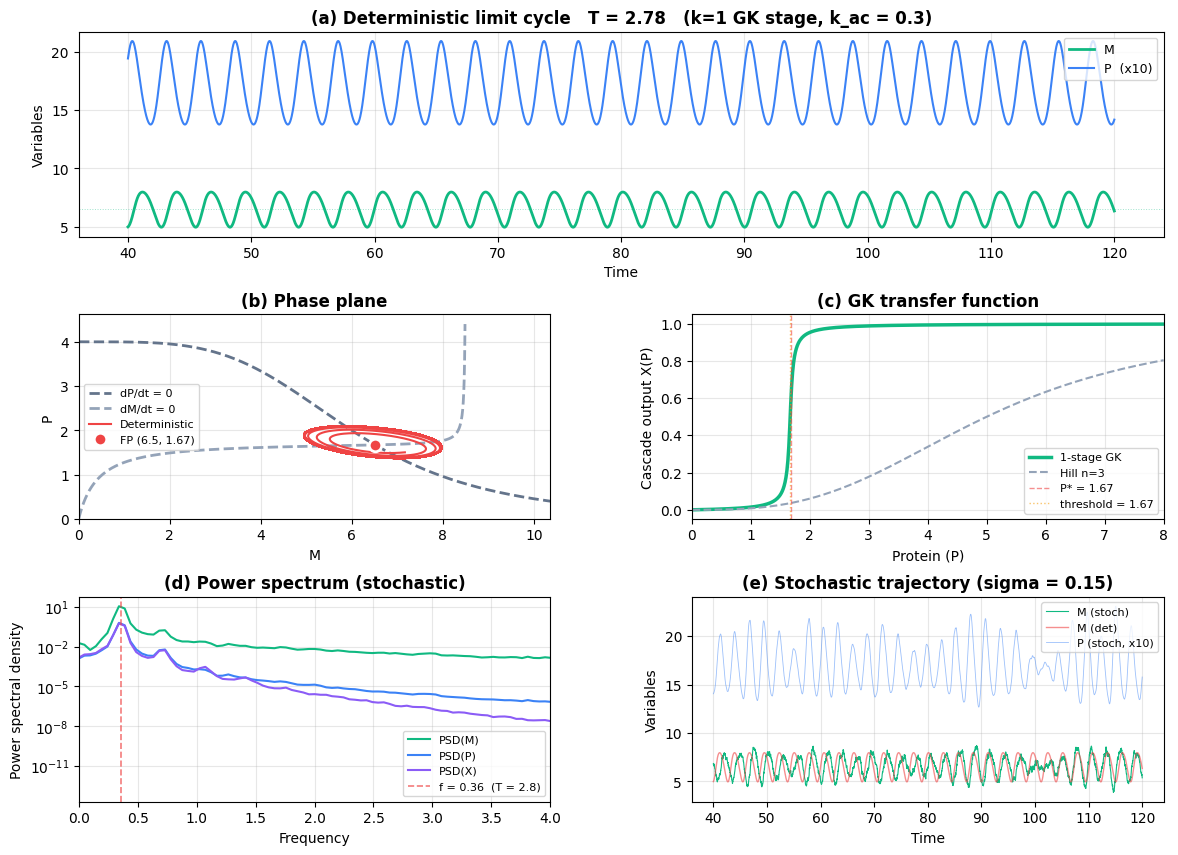


Done.


In [ ]:
# ================================================================

# k=1 Architecture 2 epigenetic oscillator with autocatalysis

#

# Architecture:  P –GK–> X –> M –Hill–| P

# + k_ac * M (autocatalysis)

#

# A single Goldbeter-Koshland covalent-modification cycle converts

# protein P into a sharp switch signal X.  X drives methylation M,

# which is further amplified by autocatalytic read-write feedback

# (k_ac > 0).  M represses protein production via a Hill function,

# closing the negative feedback loop.

#

# The GK stage operates in the zero-order regime (Ka, Kd << 1),

# giving an effective Hill coefficient n_eff ~ 1/sqrt(Ka*Kd) ~ 100

# from a single enzymatic cycle.  Combined with Hill n=4 repression

# and moderate autocatalysis (k_ac = 0.3), the total loop gain

# exceeds the Hopf bifurcation threshold and the system exhibits

# a deterministic limit cycle.

#

# References:

# Goldbeter & Koshland (1981) PNAS 78, 6840-6844

# Goodwin (1965) Adv Enzyme Regul 3, 425-437

# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, argrelmax

# ================================================================

# Parameters

# ================================================================

# Methylation dynamics

Mmax   = 8.0      # maximal methylation capacity
kp     = 3.0      # cascade-driven methylation rate
kac    = 0.3      # autocatalytic gain (read-write positive feedback)
f      = 0.05     # substrate depletion factor (= 1 / M_ceiling)
gammaM = 3.0      # methylation decay rate

# Protein dynamics (Hill repression by M)

kM     = 4.0      # maximal protein production rate
n_hill = 4        # Hill coefficient for repression
K_rep  = 6.0      # repression midpoint

# Single GK cascade stage

P_half = 5.0      # protein normalisation (cascade input = P / P_half)
tau    = 4.0     # cascade relaxation speed
Va     = 3.0      # activation Vmax  (Va > Vd shifts threshold down)
Vd     = 1.0      # deactivation Vmax
Ka     = 0.01     # activation Michaelis constant  (zero-order regime)
Kd     = 0.01     # deactivation Michaelis constant

# Numerics

dt     = 0.001    # integration time step
t_max  = 1000.0    # total simulation time

# ================================================================

# Goldbeter-Koshland steady state

# ================================================================

def gk_steady_state(S):
    # Steady-state fraction X*(S) for one GK cycle with signal S.
    # Solves the quadratic  a*X^2 + b*X + c = 0  arising from
    # Va*S*(1-X)/(Ka+1-X) = Vd*X/(Kd+X)  at steady state.
    u = Va * max(S, 0.0)
    v = Vd
    a = v - u
    b = u * (1.0 - Kd) - v * (Ka + 1.0)
    c = u * Kd
    if abs(a) < 1e-15:
        return max(0.0, min(1.0, -c / b)) if abs(b) > 1e-15 else 0.5
    disc = max(b * b - 4.0 * a * c, 0.0)
    x1 = (-b + np.sqrt(disc)) / (2.0 * a)
    x2 = (-b - np.sqrt(disc)) / (2.0 * a)
    root = min(x1, x2) if u < v else max(x1, x2)
    return max(0.0, min(1.0, root))

# ================================================================

# Fixed point

# ================================================================

def find_fixed_point():
    # Self-consistent iteration for (M*, X*, P*).
    # At steady state dM/dt=0 gives a quadratic in M (when kac != 0)
    # and dP/dt=0 gives P = kM / (1 + (M/K_rep)^n).
    P = kM / 2.0
    for _ in range(100000):
        X = gk_steady_state(P / P_half)
        A = Mmax * kac * f
        B = gammaM - Mmax * kac + Mmax * kp * X * f
        C = -Mmax * kp * X
        disc = B * B - 4.0 * A * C
        if abs(A) < 1e-15:
            M = -C / B if abs(B) > 1e-15 else 1.0
        else:
            M = (-B + np.sqrt(max(disc, 0.0))) / (2.0 * A)
        P_new = kM / (1.0 + (M / K_rep) ** n_hill)
        if abs(P_new - P) < 1e-12:
            break
        P += 0.02 * (P_new - P)
    # Final evaluation
    X = gk_steady_state(P / P_half)
    A = Mmax * kac * f
    B = gammaM - Mmax * kac + Mmax * kp * X * f
    C = -Mmax * kp * X
    if abs(A) < 1e-15:
        M = -C / B
    else:
        M = (-B + np.sqrt(max(B * B - 4.0 * A * C, 0.0))) / (2.0 * A)
    return M, X, P

# ================================================================

# Equations of motion

# ================================================================

def equations_of_motion(state):
    # Returns (d/dt [M, X, P],  methylation_rate).
    m = max(state[0], 0.0)
    x = max(0.0, min(1.0, state[1]))
    p = max(state[2], 0.0)

    # GK cascade: P activates, spontaneous deactivation
    S = p / P_half
    act   = Va * max(S, 0.0) * (1.0 - x) / (Ka + max(1.0 - x, 1e-8))
    deact = Vd * x / (Kd + max(x, 1e-8))
    dx = tau * (act - deact)

    # Methylation: driven by cascade output X plus autocatalysis
    substrate = max(1.0 - f * m, 0.0)
    rate_m    = Mmax * (kp * x + kac * m) * substrate
    dm = rate_m - gammaM * m

    # Protein: repressed by M
    dp = kM / (1.0 + (m / K_rep) ** n_hill) - p

    return np.array([dm, dx, dp]), rate_m


# ================================================================

# Numerical Jacobian and linear stability

# ================================================================

def compute_jacobian(M, X, P):
    # 3x3 Jacobian by finite differences.
    state = np.array([M, X, P])
    J = np.zeros((3, 3))
    f0, _ = equations_of_motion(state)
    for j in range(3):
        sp = state.copy()
        sp[j] += 1e-7
        fp, _ = equations_of_motion(sp)
        J[:, j] = (fp - f0) / 1e-7
    return J

# ================================================================

# Euler-Maruyama integrator

# ================================================================

def simulate(sigma=0.0, seed=42):
    # Integrate the deterministic ODE (sigma=0) or the SDE.
    # Returns sampled arrays (t, M, X, P).
    rng     = np.random.default_rng(seed)
    sqrt_dt = np.sqrt(dt)
    n_steps = int(t_max / dt)
    sample  = max(1, int(0.02 / dt))   # sample every 0.02 time units
    n_out   = n_steps // sample + 1

    # Initialise slightly off the fixed point
    M0, X0, P0 = find_fixed_point()
    state = np.array([M0 * 1.1, X0, P0 * 0.9])

    t_out = np.empty(n_out)
    M_out = np.empty(n_out)
    X_out = np.empty(n_out)
    P_out = np.empty(n_out)
    idx   = 0

    for i in range(n_steps + 1):
        if i % sample == 0 and idx < n_out:
            t_out[idx] = i * dt
            M_out[idx] = state[0]
            X_out[idx] = state[1]
            P_out[idx] = state[2]
            idx += 1

        deriv, rate_m = equations_of_motion(state)
        state += deriv * dt
        if sigma > 0.0:
            state[0] += sigma * np.sqrt(max(rate_m, 0.0)) \
                        * rng.standard_normal() * sqrt_dt

        # Enforce physical bounds
        state[0] = max(state[0], 0.0)
        state[1] = max(0.0, min(1.0, state[1]))
        state[2] = max(state[2], 0.0)

    return t_out[:idx], M_out[:idx], X_out[:idx], P_out[:idx]

# ================================================================

# Run analysis

# ================================================================

# Fixed point and linear stability

Mfp, Xfp, Pfp = find_fixed_point()
J   = compute_jacobian(Mfp, Xfp, Pfp)
eig = np.linalg.eigvals(J)
dom = max(eig, key=lambda x: x.real)
T_lin = 2.0 * np.pi / abs(dom.imag) if abs(dom.imag) > 1e-6 else float("inf")

print("=" * 62)
print("k=1  ARCHITECTURE 2  with autocatalysis  (k_ac = %.1f)" % kac)
print("  P –GK–> X –> M –Hill–| P")
print("=" * 62)
print()
print("Fixed point:  M* = %.4f   X* = %.4f   P* = %.4f" % (Mfp, Xfp, Pfp))
print()
print("Jacobian:")
labels = ["M ", "X ", "P "]
for i in range(3):
    print("  %s" % labels[i] + "  ".join("%+9.3f" % J[i, j] for j in range(3)))
print()
print("Eigenvalues:")
for lam in sorted(eig, key=lambda x: -x.real):
    if abs(lam.imag) > 1e-6:
        print("  %+.4f +/- %.4fi" % (lam.real, abs(lam.imag)))
    else:
        print("  %+.4f" % lam.real)
print()
if dom.real > 0 and abs(dom.imag) > 0.01:
    print("Classification:  UNSTABLE SPIRAL -> LIMIT CYCLE")
else:
    print("Classification:  STABLE")
print("Linearised period:  T_0 = %.2f" % T_lin)
print("=" * 62)

# Integrate

print("\nRunning deterministic simulation...")
td, Md, Xd, Pd = simulate(sigma=0.0)
print("Running stochastic simulation (sigma = 0.15)...")
ts, Ms, Xs, Ps = simulate(sigma=0.15, seed=2025)

# Measure nonlinear period

skip  = len(Md) // 4
peaks = argrelmax(Md[skip:], order=20)[0]
T_meas = np.mean(np.diff(td[skip:][peaks])) if len(peaks) > 2 else T_lin
print("Measured deterministic period:  T = %.2f" % T_meas)

# ================================================================

# Figure: five-panel summary

# ================================================================

fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(3, 2, hspace=0.38, wspace=0.30)

# ── (a) Deterministic waveforms ──────────────────────────────────

ax_a = fig.add_subplot(gs[0, :])
t1, t2 = 40, 120
md = (td >= t1) & (td <= t2)
ax_a.plot(td[md], Md[md], color="#10b981", lw=2.0, label="M")
ax_a.plot(td[md], Pd[md] * 10, color="#3b82f6", lw=1.5, label="P  (x10)")
#ax_a.plot(td[md], Xd[md] * 10, color="#8b5cf6", lw=1.5, label="X  (x10)")
ax_a.axhline(Mfp, ls=":", color="#10b981", lw=0.7, alpha=0.4)
ax_a.set_xlabel("Time")
ax_a.set_ylabel("Variables")
ax_a.set_title(
"(a) Deterministic limit cycle   T = %.2f   " # Corrected smart quotes from previous diff
"(k=1 GK stage, k_ac = %.1f)" % (T_meas, kac),
fontsize=12, fontweight="bold")
ax_a.legend(loc="upper right", fontsize=9)
ax_a.grid(True, alpha=0.3)

# ── (b) Phase plane M vs P ──────────────────────────────────────

ax_b = fig.add_subplot(gs[1, 0])

# P-nullcline:  P = kM / (1 + (M/K_rep)^n)

m_arr = np.linspace(0.01, min(0.9 / f, np.max(Md) * 1.3), 400)
P_null = kM / (1.0 + (m_arr / K_rep) ** n_hill)
ax_b.plot(m_arr, P_null, color="#64748b", lw=2, ls="--", label="dP/dt = 0") # Corrected smart quotes

# M-nullcline (parametric in P)

p_arr = np.linspace(0.01, kM * 1.1, 400)
M_nc  = np.zeros_like(p_arr)
for j, pv in enumerate(p_arr):
    xv = gk_steady_state(pv / P_half)
    A_ = Mmax * kac * f
    B_ = gammaM - Mmax * kac + Mmax * kp * xv * f
    C_ = -Mmax * kp * xv
    if abs(A_) < 1e-15:
        M_nc[j] = max(-C_ / B_, 0) if abs(B_) > 1e-15 else 0
    else:
        d_ = B_ * B_ - 4 * A_ * C_
        M_nc[j] = max((-B_ + np.sqrt(max(d_, 0))) / (2 * A_), 0)
ok = (M_nc > 0) & (M_nc < max(m_arr))
ax_b.plot(M_nc[ok], p_arr[ok], color="#94a3b8", lw=2, ls="--", label="dM/dt = 0") # Corrected smart quotes
ax_b.plot(Md, Pd, color="#ef4444", lw=1.5, zorder=5, label="Deterministic")
ax_b.plot(Mfp, Pfp, "o", color="#ef4444", ms=9, mew=2, mec="white",
zorder=10, label="FP (%.1f, %.2f)" % (Mfp, Pfp))
ax_b.set_xlabel("M")
ax_b.set_ylabel("P")
ax_b.set_title("(b) Phase plane", fontsize=12, fontweight="bold")
ax_b.legend(fontsize=8)
ax_b.set_xlim(0, max(m_arr))
ax_b.set_ylim(bottom=0)
ax_b.grid(True, alpha=0.3)

# ── (c) GK transfer function ────────────────────────────────────

ax_c = fig.add_subplot(gs[1, 1])
p_test = np.linspace(0.01, 8, 500)
x_test = np.array([gk_steady_state(p / P_half) for p in p_test])
ax_c.plot(p_test, x_test, color="#10b981", lw=2.5, label="1-stage GK")
ax_c.plot(p_test, (p_test / P_half)**3 / (1 + (p_test / P_half)**3),
color="#94a3b8", ls="--", lw=1.5, label="Hill n=3") # Corrected smart quotes
ax_c.axvline(Pfp, color="#ef4444", ls="--", lw=1, alpha=0.6, # Corrected smart quotes
label="P* = %.2f" % Pfp)
thresh = P_half * Vd / Va
ax_c.axvline(thresh, color="#f59e0b", ls=":", lw=1, alpha=0.6, # Corrected smart quotes
label="threshold = %.2f" % thresh)
ax_c.set_xlabel("Protein (P)")
ax_c.set_ylabel("Cascade output X(P)")
ax_c.set_title("(c) GK transfer function", fontsize=12, fontweight="bold")
ax_c.legend(fontsize=8)
ax_c.set_xlim(0, 8)
ax_c.set_ylim(-0.05, 1.05)
ax_c.grid(True, alpha=0.3)

# ── (d) Power spectrum ───────────────────────────────────────────

ax_d = fig.add_subplot(gs[2, 0])
dt_s    = ts[1] - ts[0]
nperseg = min(1024, len(Ms) // 2)
fM, pM  = welch(Ms - np.mean(Ms), fs=1/dt_s, nperseg=nperseg, window="hann")
fP, pP  = welch(Ps - np.mean(Ps), fs=1/dt_s, nperseg=nperseg, window="hann")
fX, pX  = welch(Xs - np.mean(Xs), fs=1/dt_s, nperseg=nperseg, window="hann")
ax_d.semilogy(fM, pM, color="#10b981", lw=1.5, label="PSD(M)")
ax_d.semilogy(fP, pP, color="#3b82f6", lw=1.5, label="PSD(P)")
ax_d.semilogy(fX, pX, color="#8b5cf6", lw=1.5, label="PSD(X)")
if T_meas > 0:
    ax_d.axvline(1.0 / T_meas, color="#ef4444", ls="--", lw=1.2, alpha=0.7, # Corrected smart quotes
    label="f = %.2f  (T = %.1f)" % (1.0/T_meas, T_meas))
ax_d.set_xlabel("Frequency")
ax_d.set_ylabel("Power spectral density")
ax_d.set_title("(d) Power spectrum (stochastic)", fontsize=12, fontweight="bold")
ax_d.set_xlim(0, 4)
ax_d.legend(fontsize=8)
ax_d.grid(True, alpha=0.3)

# ── (e) Stochastic vs deterministic ─────────────────────────────

ax_e = fig.add_subplot(gs[2, 1])
ms = (ts >= t1) & (ts <= t2)
ax_e.plot(ts[ms], Ms[ms], color="#10b981", lw=0.8, label="M (stoch)")
ax_e.plot(td[md], Md[md], color="#ef4444", lw=1.0, alpha=0.6, label="M (det)")
ax_e.plot(ts[ms], Ps[ms] * 10, color="#3b82f6", lw=0.6, alpha=0.5,
label="P (stoch, x10)")
ax_e.set_xlabel("Time")
ax_e.set_ylabel("Variables")
ax_e.set_title("(e) Stochastic trajectory (sigma = 0.15)",
fontsize=12, fontweight="bold")
ax_e.legend(fontsize=8, loc="upper right")
ax_e.grid(True, alpha=0.3)

plt.savefig("k1_autocatalytic_oscillator.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDone.")